Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from collections import Counter

Load Dataset

In [2]:
file_path = "../data/raw/wikitext.txt"

with open(file_path, "r", encoding="utf-8") as f:
    text = f.read()

print("Dataset Loaded Successfully")
print(f"Total Characters: {len(text):,}")

Dataset Loaded Successfully
Total Characters: 10,929,707


Dataset Preview

In [3]:
print(text[:2000])


 = Valkyria Chronicles III = 


 Senjō no Valkyria 3 : Unrecorded Chronicles ( Japanese : 戦場のヴァルキュリア3 , lit . Valkyria of the Battlefield 3 ) , commonly referred to as Valkyria Chronicles III outside Japan , is a tactical role @-@ playing video game developed by Sega and Media.Vision for the PlayStation Portable . Released in January 2011 in Japan , it is the third game in the Valkyria series . Employing the same fusion of tactical and real @-@ time gameplay as its predecessors , the story runs parallel to the first game and follows the " Nameless " , a penal military unit serving the nation of Gallia during the Second Europan War who perform secret black operations and are pitted against the Imperial unit " Calamaty Raven " . 

 The game began development in 2010 , carrying over a large portion of the work done on Valkyria Chronicles II . While it retained the standard features of the series , it also underwent multiple adjustments , such as making the game more forgiving for series 

Basic Statistics

In [4]:
words = text.split()

print("Total Words:", len(words))
print("Unique Words:", len(set(words)))
print("Vocabulary Ratio:", round(len(set(words))/len(words), 4))

Total Words: 2051910
Unique Words: 76616
Vocabulary Ratio: 0.0373


Sentance Statistics

In [5]:
sentences = text.split("\n")

sentences = [s.strip() for s in sentences if s.strip()]

sentence_lengths = [len(sentence.split()) for sentence in sentences]

print("Total Sentences:", len(sentences))
print("Average Sentence Length:", np.mean(sentence_lengths))
print("Maximum Sentence Length:", np.max(sentence_lengths))
print("Minimum Sentence Length:", np.min(sentence_lengths))

Total Sentences: 23767
Average Sentence Length: 86.33441326208609
Maximum Sentence Length: 699
Minimum Sentence Length: 1


Word Length Statistics

In [6]:
word_lengths = [len(word) for word in words]

stats = pd.Series(word_lengths).describe()

stats

count    2.051910e+06
mean     4.285518e+00
std      2.752215e+00
min      1.000000e+00
25%      2.000000e+00
50%      4.000000e+00
75%      6.000000e+00
max      2.600000e+01
dtype: float64

Distribution of Word Lengths

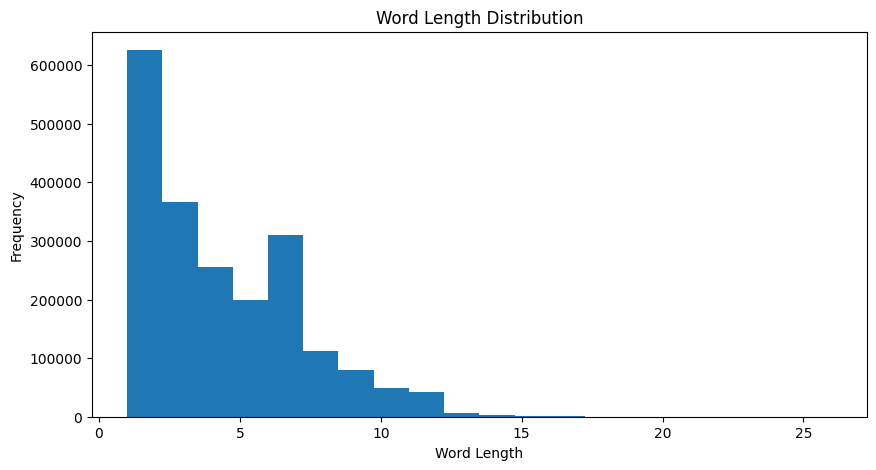

In [7]:
plt.figure(figsize=(10,5))

plt.hist(word_lengths, bins=20)

plt.title("Word Length Distribution")
plt.xlabel("Word Length")
plt.ylabel("Frequency")

plt.show()

Most Frequent Words

In [8]:
counter = Counter(words)

top_words = counter.most_common(20)

top_words

[('the', 113161),
 (',', 99913),
 ('.', 73388),
 ('of', 56889),
 ('and', 50603),
 ('in', 39453),
 ('to', 39190),
 ('a', 34237),
 ('=', 29570),
 ('"', 28309),
 ('was', 20985),
 ('The', 17602),
 ('@-@', 16906),
 ('that', 14135),
 ('as', 14021),
 ("'s", 14002),
 ('on', 13678),
 ('for', 13307),
 ('with', 12606),
 ('by', 12148)]

Top 20 Word Frequency Plot

In [9]:
top_words_df = pd.DataFrame(
    top_words,
    columns=["Word", "Frequency"]
)

top_words_df

,Word,Frequency
0,the,113161
1,",",99913
2,.,73388
3,of,56889
4,and,50603
5,in,39453
6,to,39190
7,a,34237
8,=,29570
9,"""",28309


Visualization

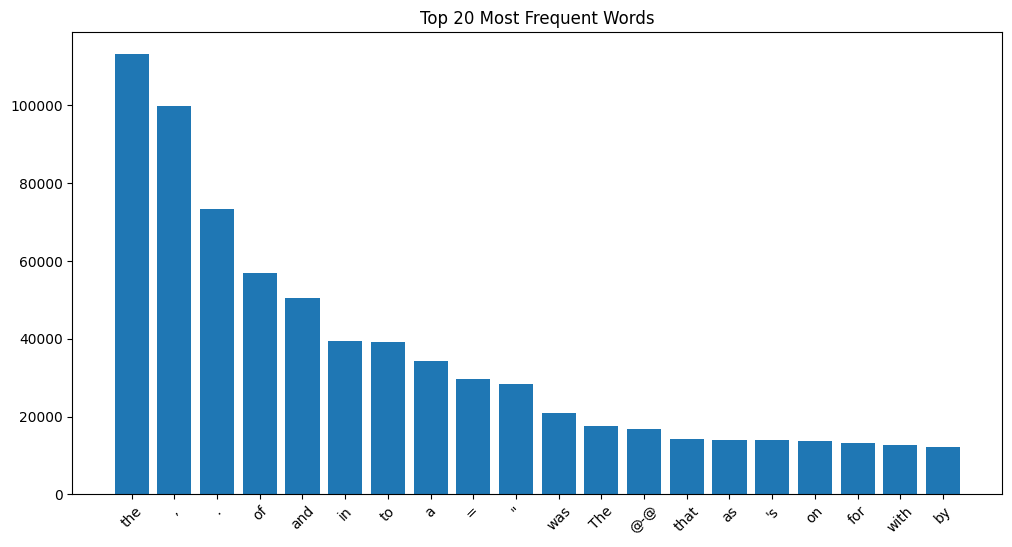

In [10]:
plt.figure(figsize=(12,6))

plt.bar(
    top_words_df["Word"],
    top_words_df["Frequency"]
)

plt.xticks(rotation=45)

plt.title("Top 20 Most Frequent Words")

plt.show()

Vocabulary Growth Analysis

In [11]:
vocab_growth = []

seen_words = set()

for i, word in enumerate(words[:100000]):

    seen_words.add(word)

    if i % 1000 == 0:
        vocab_growth.append(len(seen_words))

Vocabulary Growth Plot

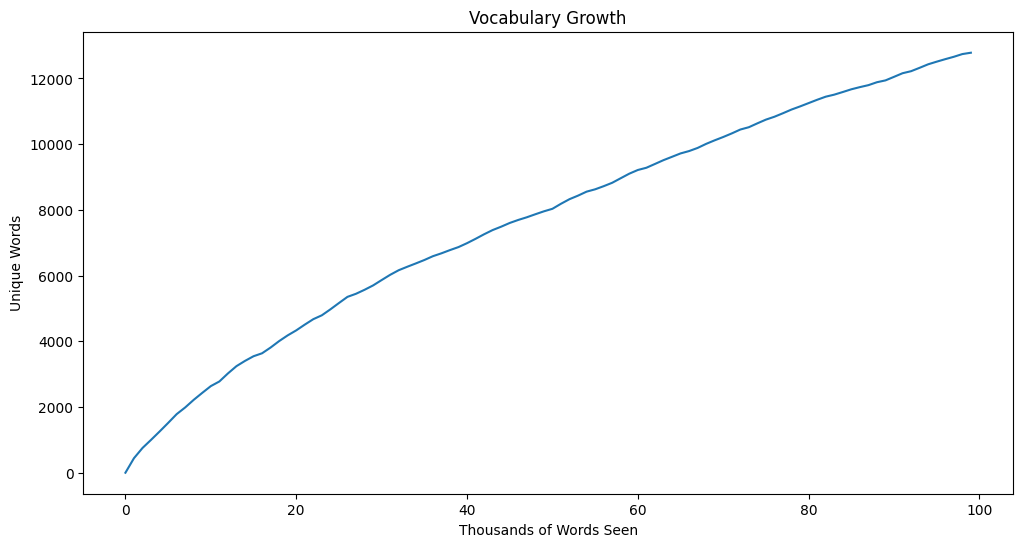

In [12]:
plt.figure(figsize=(12,6))

plt.plot(vocab_growth)

plt.title("Vocabulary Growth")
plt.xlabel("Thousands of Words Seen")
plt.ylabel("Unique Words")

plt.show()

Top 50 Words Table

In [13]:
top50 = pd.DataFrame(
    counter.most_common(50),
    columns=["Word", "Frequency"]
)

top50

,Word,Frequency
0,the,113161
1,",",99913
2,.,73388
3,of,56889
4,and,50603
5,in,39453
6,to,39190
7,a,34237
8,=,29570
9,"""",28309


Dataset Quality Check

In [14]:
empty_lines = sum(
    1 for line in text.split("\n")
    if len(line.strip()) == 0
)

print("Empty Lines:", empty_lines)

Empty Lines: 36718


Summary

In [15]:
print("="*50)

print("DATASET SUMMARY")

print("="*50)

print(f"Total Words      : {len(words):,}")
print(f"Unique Words     : {len(set(words)):,}")
print(f"Total Sentences  : {len(sentences):,}")
print(f"Avg Sent Length  : {round(np.mean(sentence_lengths),2)}")
print(f"Max Sent Length  : {max(sentence_lengths)}")

print("="*50)

DATASET SUMMARY
Total Words      : 2,051,910
Unique Words     : 76,616
Total Sentences  : 23,767
Avg Sent Length  : 86.33
Max Sent Length  : 699
